# 02 · Displacement map of a perovskite [100] image (complete cages)

Data: `data/PTO10040nmHAADF.dm4`, a Dr. Probe multislice simulation of PbTiO₃
viewed along [100] (40 nm thick, HAADF, probe-convolved), from the VecMap
repository. Reading DM4 files requires HyperSpy (`pip install "polarmap[io]"`).

The quantity measured is the displacement of each Ti column from the centroid
of its four surrounding Pb columns.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

import polarmap as pm
from polarmap import plotting

plt.rcParams["figure.dpi"] = 80
print("polarmap", pm.__version__)

polarmap 0.1.0


image (258, 244), sampling 0.016 nm/px


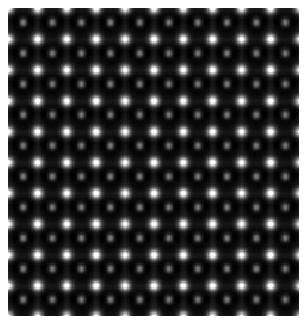

In [2]:
image, sampling = pm.load_image("data/PTO10040nmHAADF.dm4")
print(f"image {image.shape}, sampling {sampling:.5g} nm/px")
fig, ax = plt.subplots(figsize=(5, 5))
plotting.show_image(ax, image); ax.axis("off");

## 1. Pb (A-site) columns

`min_distance` is set to the Pb–Pb spacing (about 30 px here) so that the weaker
Ti columns, only a/√2 away, are not detected. Check that every Pb column carries
exactly one marker.

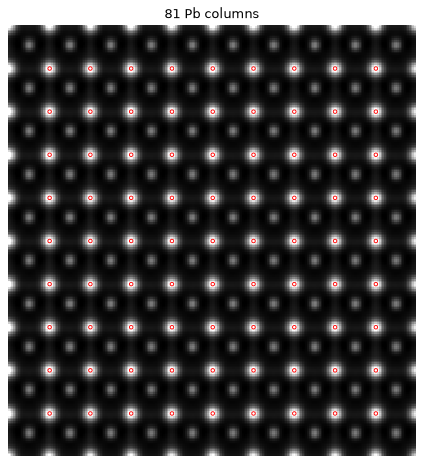

In [3]:
SEP = 30
seeds = pm.detect_peaks(image, min_distance=SEP, threshold_rel=0.20, exclude_border=5)
A = pm.refine_gaussian(image, seeds, box=SEP // 3)
plotting.plot_columns(image, A, title=f"{len(A)} Pb columns");

### Position precision proxy

Agreement between the Gaussian fit and the centre of mass of each column.

In [4]:
precision = pm.compare_refinements(image, seeds, sampling, box=SEP // 3)
print(f"Gaussian vs centre of mass: RMS {precision['rms_pm']:.1f} pm, "
      f"median {precision['median_pm']:.1f} pm")

Gaussian vs centre of mass: RMS 2.2 pm, median 2.1 pm


## 2. Lattice vectors

v1 = [24.4 -0. ] px   v2 = [ 0.  25.8] px
|v1| = 0.3904 nm, |v2| = 0.4128 nm


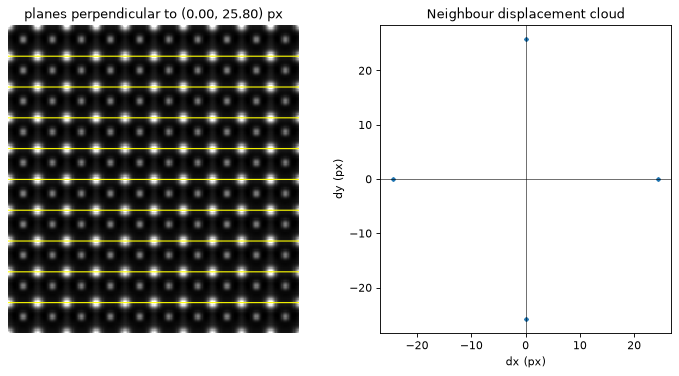

In [5]:
v1, v2 = pm.estimate_lattice_vectors(A)
print("v1 =", np.round(v1, 2), "px   v2 =", np.round(v2, 2), "px")
print(f"|v1| = {np.linalg.norm(v1) * sampling:.4f} nm, |v2| = {np.linalg.norm(v2) * sampling:.4f} nm")
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plotting.plot_lattice_planes(image, A, v2, ax=axes[0], n_planes=9)
plotting.plot_neighbor_cloud(A, ax=axes[1]);

## 3. Ti displacement in every complete cage

The Pb columns are subtracted first so that their tails do not pull the fit of
the weaker Ti column. Only cages with all four Pb corners measured are used; the
diagnostic shows the residual image, the cages, their centroids (red) and the
fitted Ti columns (yellow).

64 complete cages measured


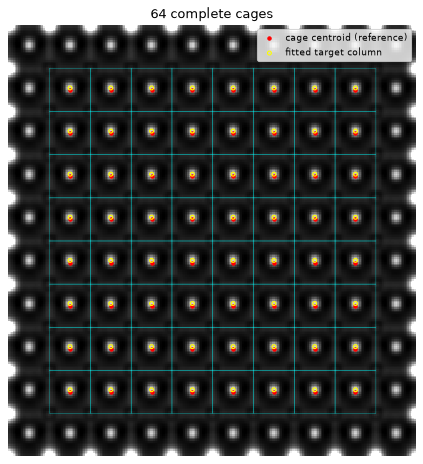

In [6]:
field = pm.measure_cage_displacement(image, A, v1, v2)
print(f"{len(field)} complete cages measured")
plotting.plot_cages(field, A);

## 4. Statistics

Orientations use the Cartesian convention (0° right, +90° up).

Displacement descriptors (n = 64, 0 excluded as outliers)
  magnitude |d| (pm): mean 20.5  median 20.5  std 0.0  MAD 0.0  min 20.5  max 20.6
  orientation (cartesian, deg): circular mean 90.0  circular std 0.1  (R = 1.00)


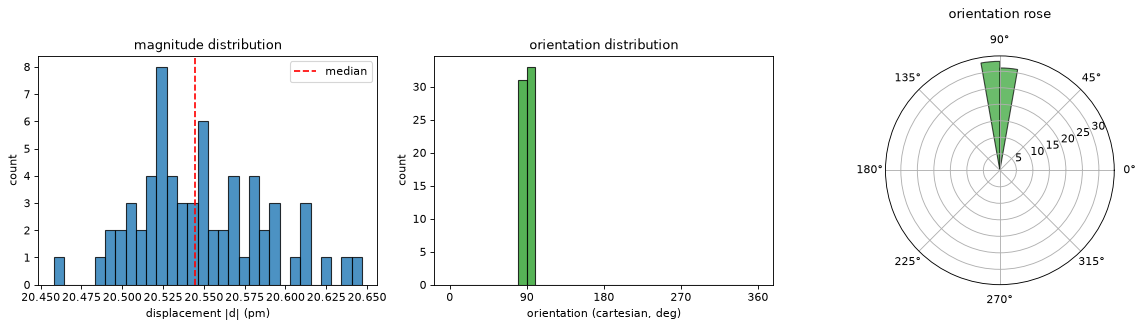

In [7]:
fig, axes, desc = plotting.plot_displacement_statistics(field, sampling)
print(pm.format_descriptors(desc))

## 5. Figures

Arrows show magnitude and direction together; colour maps are easier to read
when only one of them matters.

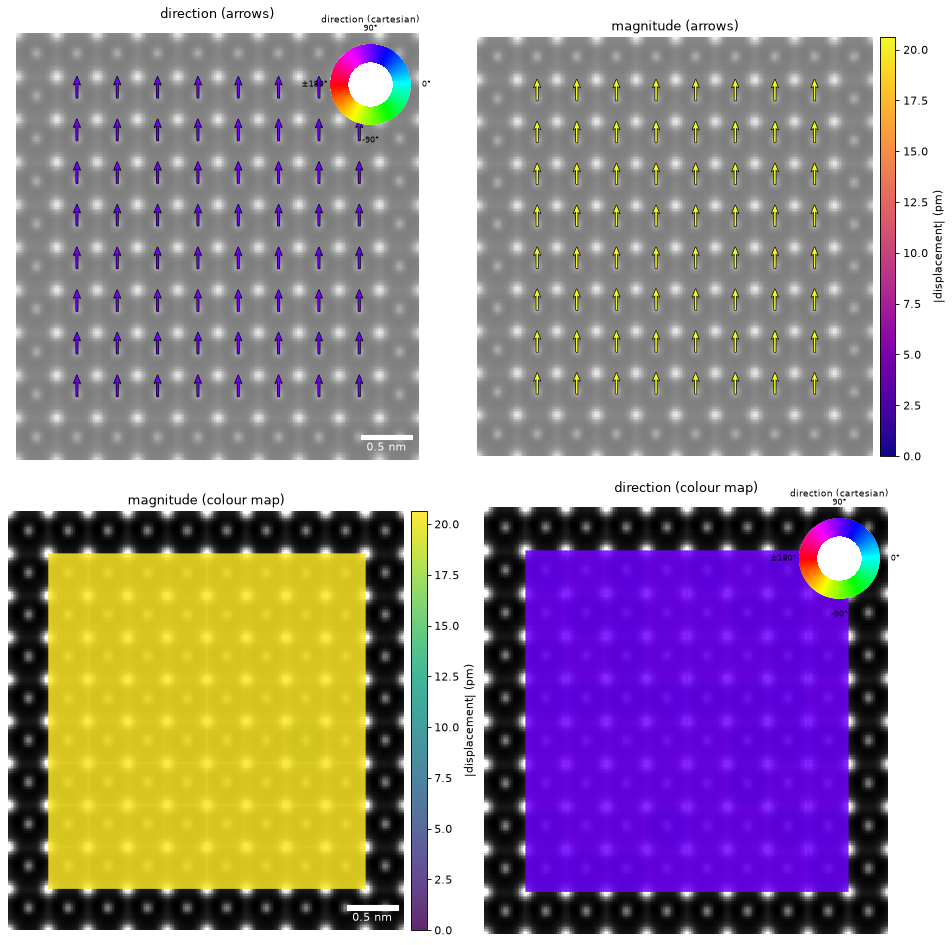

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
plotting.plot_displacement_vectors(field, image, ax=axes[0, 0], color_by="angle",
                                   sampling=sampling, scalebar_nm="auto",
                                   title="direction (arrows)")
plotting.plot_displacement_vectors(field, image, ax=axes[0, 1], color_by="magnitude",
                                   sampling=sampling, title="magnitude (arrows)")
plotting.plot_displacement_map(field, "magnitude", ax=axes[1, 0], image=image,
                               sampling=sampling, alpha=0.85, scalebar_nm="auto",
                               title="magnitude (colour map)")
plotting.plot_displacement_map(field, "angle", ax=axes[1, 1], image=image,
                               alpha=0.85, title="direction (colour map)")
fig.tight_layout()

## 6. Displacement → polarization (semi-quantitative)

With the Born effective charge of Ti in PbTiO₃ (about 7.1 e) and the unit-cell
volume. This single-sublattice estimate ignores the oxygen displacements; report
the displacement (pm) as the measured quantity.

In [9]:
P = pm.displacement_to_polarization(desc["median_pm"], z_star=7.1,
                                    cell_volume_nm3=0.402 * 0.402 * 0.413)
print(f"median |d| = {desc['median_pm']:.2f} pm  ->  P ~ {P:.1f} µC/cm²")

median |d| = 20.54 pm  ->  P ~ 35.0 µC/cm²


## 7. Export

The CSV file contains reference and target positions, components and magnitude
(px and pm) and the orientation.

In [10]:
from pathlib import Path

Path("output").mkdir(exist_ok=True)
field.to_csv("output/PTO100_displacements.csv", sampling=sampling)
fig.savefig("output/PTO100_maps.png", dpi=200, bbox_inches="tight")

## 8. (Optional) Comparison with VecMap

If you have analysed the same image with VecMap, load its B-site displacement
table and compare column by column:

In [11]:
vecmap_csv = Path("data/PTO100-40nm-HAADF-B-site-disp.csv")      # exported by VecMap
if vecmap_csv.exists():
    vecmap = pm.load_vecmap_csv(vecmap_csv)
    cmp = pm.compare_displacement_fields(field, vecmap, sampling)
    print({k: round(v, 3) for k, v in cmp.items() if np.isscalar(v)})
    plotting.plot_magnitude_agreement(cmp, labels=("polarmap", "VecMap"))
else:
    print("no VecMap file found; skipping the comparison")

no VecMap file found; skipping the comparison
